# Preprocesamiento de datos

In [1]:
import os
import kagglehub
import shutil
import random

## 1. Carga de datos

In [2]:
# Downloads the latest version of the 'fruits' dataset from Kaggle Hub.
# 'path' will store the local path where the dataset files are saved.
path = kagglehub.dataset_download("moltean/fruits")

print("Path to dataset files:", path)

100%|██████████| 5.99G/5.99G [03:42<00:00, 29.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/moltean/fruits/versions/94


In [3]:
# Define source and destination paths to organize the dataset.
# SOURCE_PATH: Original path of the downloaded dataset from Kaggle.
# DATASET_PATH: Base path where the organized dataset (Training, Test, Validation) will be created.
# TRAINING_PATH, TEST_PATH, VALIDATION_PATH: Specific paths for each data split.
# SUB_DIRECTORIES: Original folders within SOURCE_PATH that contain images.

SOURCE_PATH = path + "/fruits-360_100x100/fruits-360"
DATASET_PATH = "/content/fruits_dataset"
TRAINING_PATH = DATASET_PATH + "/Training"
TEST_PATH = DATASET_PATH + "/Test"
VALIDATION_PATH = DATASET_PATH + "/Validation"
SUB_DIRECTORIES = ["Training", "Test"]

# Check if path exists.
if os.path.exists(SOURCE_PATH):
    print(f"Source path exits: {SOURCE_PATH}")
if os.path.exists(os.path.join(SOURCE_PATH, SUB_DIRECTORIES[0])):
    print(f"Training path exists: {os.path.join(SOURCE_PATH, SUB_DIRECTORIES[0])}")
if os.path.exists(os.path.join(SOURCE_PATH, SUB_DIRECTORIES[1])):
    print(f"Test path exists: {os.path.join(SOURCE_PATH, SUB_DIRECTORIES[1])}")

Source path exits: /root/.cache/kagglehub/datasets/moltean/fruits/versions/94/fruits-360_100x100/fruits-360
Training path exists: /root/.cache/kagglehub/datasets/moltean/fruits/versions/94/fruits-360_100x100/fruits-360/Training
Test path exists: /root/.cache/kagglehub/datasets/moltean/fruits/versions/94/fruits-360_100x100/fruits-360/Test


## 2. Estructura y división de conjuntos

In [4]:
def split_data(source_path, dataset_path):
    """
    Reorganizes and splits the original dataset images into Training, Validation, and Test
    following a strategy of 70% Training, 10% Validation, 20% Test.

    Args:
        source_path (str): Path to the original downloaded dataset.
        dataset_path (str): Path where the new directory structure will be created.
    """
    # Iterate over 'Training' and 'Test' from the original dataset
    for split in SUB_DIRECTORIES:
        source_split_path = os.path.join(source_path, split)

        # Verify the split folder exists before processing.
        if not os.path.exists(source_split_path):
            print(f"Folder not found: {source_split_path}")
            continue

        print(f"Processing '{split}' folder...")

        # Iterate over all subdirectories within each split.
        for sub_dir_name in os.listdir(source_split_path):
            sub_dir_path = os.path.join(source_split_path, sub_dir_name)

            # Process only if it is a directory.
            if os.path.isdir(sub_dir_path):
                # Extract the base category name.
                base_category = sub_dir_name.split(' ')[0].capitalize()
                # Get all images
                all_images = [f for f in os.listdir(sub_dir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                distribution = {}

                if split == "Training":
                    # Randomly shuffle images
                    random.shuffle(all_images)

                    # Calculate 10% for validation size.
                    val_size = int(len(all_images) * 0.10)

                    # Distribute images between Validation and Training.
                    distribution["Validation"] = all_images[:val_size]
                    distribution["Training"] = all_images[val_size:]
                else:
                    # If it's the 'Test' split, all images go directly to the Test folder.
                    distribution[split] = all_images

                # Move images to their respective destinations.
                for target_split, images_list in distribution.items():
                    # Create the destination path for the current category and split.
                    new_category_path = os.path.join(dataset_path, target_split, base_category)
                    os.makedirs(new_category_path, exist_ok=True) # Create the directory if it doesn't exist.

                    for file_name in images_list:
                        source_file_path = os.path.join(sub_dir_path, file_name)

                        # Rename the file to prevent overwriting if there are duplicate names in different subfolders.
                        new_file_name = f"{sub_dir_name}_{file_name}"
                        dest_file_path = os.path.join(new_category_path, new_file_name)
                        shutil.copy(source_file_path, dest_file_path)

    print(f"\nOrganization complete! Your clean dataset is ready at: {dataset_path}")

In [5]:
# Call the 'split_data' function to organize the dataset.
split_data(SOURCE_PATH, DATASET_PATH)

Processing 'Training' folder...
Processing 'Test' folder...

Organization complete! Your clean dataset is ready at: /content/fruits_dataset


## 3. Análisis volumétrico inicial

In [6]:
# Check the distribution of images in the newly created folders (Training, Validation, Test).
for split in ['Training', 'Validation', 'Test']:
    split_path = os.path.join(DATASET_PATH, split)
    if os.path.exists(split_path):
        # Count the total images in each subdirectory of the split.
        count = sum([len(files) for r, d, files in os.walk(split_path)])
        print(f"Total images in {split}: {count}")
    else:
        print(f"Folder not found: {split}")

Total images in Training: 123586
Total images in Validation: 13635
Total images in Test: 45724


In [7]:
def print_categories(dataset_path):
    """
    Prints a summary of categories and image distribution within a specific dataset.

    Args:
        dataset_path (str): Path to the root directory of the dataset.
    """
    # Get a sorted list of subfolder names (categories).
    categories = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])

    print(f"Dataset Summary")
    print(f"Total categories found: {len(categories)}")
    print(f"Categories: {categories}\n")

    print("Image distribution:")
    # Iterate over each category to count and display the number of images.
    for cat in categories:
        path = os.path.join(dataset_path, cat)
        num_images = len(os.listdir(path))
        print(f"- {cat}: {num_images} images")

### Training

In [8]:
print_categories(TRAINING_PATH)

Dataset Summary
Total categories found: 79
Categories: ['Almonds', 'Apple', 'Apricot', 'Avocado', 'Banana', 'Bean', 'Beetroot', 'Blackberry', 'Blueberry', 'Cabbage', 'Cactus', 'Caju', 'Cantaloupe', 'Carambola', 'Carrot', 'Cauliflower', 'Celery', 'Cherimoya', 'Cherry', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Cucumber', 'Dates', 'Eggplant', 'Fig', 'Ginger', 'Gooseberry', 'Granadilla', 'Grape', 'Grapefruit', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mangostan', 'Maracuja', 'Melon', 'Mulberry', 'Nectarine', 'Nut', 'Onion', 'Orange', 'Papaya', 'Passion', 'Peach', 'Peanut', 'Pear', 'Pepino', 'Pepper', 'Physalis', 'Pineapple', 'Pistachio', 'Pitahaya', 'Plum', 'Pomegranate', 'Pomelo', 'Potato', 'Quince', 'Rambutan', 'Raspberry', 'Redcurrant', 'Salak', 'Strawberry', 'Tamarillo', 'Tangelo', 'Tomato', 'Walnut', 'Watermelon', 'Zucchini']

Image distribution:
- Almonds: 209 images
- Apple: 14925 images
- Aprico

### Validation

In [9]:
print_categories(VALIDATION_PATH)

Dataset Summary
Total categories found: 79
Categories: ['Almonds', 'Apple', 'Apricot', 'Avocado', 'Banana', 'Bean', 'Beetroot', 'Blackberry', 'Blueberry', 'Cabbage', 'Cactus', 'Caju', 'Cantaloupe', 'Carambola', 'Carrot', 'Cauliflower', 'Celery', 'Cherimoya', 'Cherry', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Cucumber', 'Dates', 'Eggplant', 'Fig', 'Ginger', 'Gooseberry', 'Granadilla', 'Grape', 'Grapefruit', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mangostan', 'Maracuja', 'Melon', 'Mulberry', 'Nectarine', 'Nut', 'Onion', 'Orange', 'Papaya', 'Passion', 'Peach', 'Peanut', 'Pear', 'Pepino', 'Pepper', 'Physalis', 'Pineapple', 'Pistachio', 'Pitahaya', 'Plum', 'Pomegranate', 'Pomelo', 'Potato', 'Quince', 'Rambutan', 'Raspberry', 'Redcurrant', 'Salak', 'Strawberry', 'Tamarillo', 'Tangelo', 'Tomato', 'Walnut', 'Watermelon', 'Zucchini']

Image distribution:
- Almonds: 23 images
- Apple: 1646 images
- Apricot:

### Test

In [10]:
print_categories(TEST_PATH)

Dataset Summary
Total categories found: 79
Categories: ['Almonds', 'Apple', 'Apricot', 'Avocado', 'Banana', 'Bean', 'Beetroot', 'Blackberry', 'Blueberry', 'Cabbage', 'Cactus', 'Caju', 'Cantaloupe', 'Carambola', 'Carrot', 'Cauliflower', 'Celery', 'Cherimoya', 'Cherry', 'Chestnut', 'Clementine', 'Cocos', 'Corn', 'Cucumber', 'Dates', 'Eggplant', 'Fig', 'Ginger', 'Gooseberry', 'Granadilla', 'Grape', 'Grapefruit', 'Guava', 'Hazelnut', 'Huckleberry', 'Kaki', 'Kiwi', 'Kohlrabi', 'Kumquats', 'Lemon', 'Limes', 'Lychee', 'Mandarine', 'Mango', 'Mangostan', 'Maracuja', 'Melon', 'Mulberry', 'Nectarine', 'Nut', 'Onion', 'Orange', 'Papaya', 'Passion', 'Peach', 'Peanut', 'Pear', 'Pepino', 'Pepper', 'Physalis', 'Pineapple', 'Pistachio', 'Pitahaya', 'Plum', 'Pomegranate', 'Pomelo', 'Potato', 'Quince', 'Rambutan', 'Raspberry', 'Redcurrant', 'Salak', 'Strawberry', 'Tamarillo', 'Tangelo', 'Tomato', 'Walnut', 'Watermelon', 'Zucchini']

Image distribution:
- Almonds: 77 images
- Apple: 5506 images
- Apricot:

## 4. Diagnóstico visual de distribución

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_class_distribution(dataset_path, threshold):
    """
    Analyzes an image folder classified by categories and generates a bar chart
    showing the class balance, with a critical threshold.

    Args:
        dataset_path (str): Path to the root directory of the dataset.
        threshold (int): Critical threshold value for the number of images per class.
    """
    print(f"Generating plot for: {dataset_path}...")

    # 1. Count images per class.
    class_counts = {}

    if not os.path.exists(dataset_path):
        print(f"Error: Path not found {dataset_path}")
        return

    # Iterate over each category in the dataset.
    for category in os.listdir(dataset_path):
        category_path = os.path.join(dataset_path, category)
        if os.path.isdir(category_path):
            # Count only valid image files.
            num_images = len([f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            class_counts[category] = num_images

    # Check if the folder is empty or has no images.
    if not class_counts:
        print("No categories or images found in the specified path.")
        return

    # Sort data from highest to lowest image count.
    classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)
    categories = [item[0] for item in classes]
    counts = [item[1] for item in classes]

    # Visualization Setup.
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.1)
    fig, ax = plt.subplots(figsize=(22, 8), dpi=100)

    # Bar colors
    color_excess = '#ff6b6b'
    color_ok = '#4ecdc4'
    bar_colors = [color_excess if count > threshold else color_ok for count in counts]

    # Draw the bar chart.
    bars = ax.bar(range(len(categories)), counts, color=bar_colors,
                  width=0.8, edgecolor='black', linewidth=0.5, alpha=0.9)

    # Draw the threshold.
    ax.axhline(y=threshold, color='#2d3436', linestyle='--', linewidth=2.5,
               label=f'Critical threshold ({threshold})')

    # Upper limit
    max_height = max(counts) if counts else threshold
    ax.set_ylim(0, max_height * 1.35)

    # Place category names at the top of each bar.
    for i, bar in enumerate(bars):
        yval = bar.get_height()
        margin_y = max_height * 0.02
        ax.text(bar.get_x() + bar.get_width() / 2.0, yval + margin_y, categories[i],
                ha='center', va='bottom', rotation=90, fontsize=10,
                fontweight='medium', color='#2d3436')

    # Text and axis formatting.
    ax.set_title("Dataset Distribution", fontsize=20, fontweight='bold', pad=20, color='#2d3436')
    ax.set_xlabel(f'Ordered Categories (Total Classes: {len(categories)})',
                  fontsize=14, labelpad=15, color='#2d3436')
    ax.set_ylabel('Number of Images', fontsize=14, labelpad=15, color='#2d3436')
    ax.set_xticks([])
    sns.despine(left=False, bottom=True, top=True, right=True)
    ax.grid(axis='y', linestyle=':', alpha=0.6, color='gray')
    ax.legend(fontsize=12, loc='upper right', frameon=True, shadow=True, borderpad=1)
    plt.tight_layout()
    plt.show()

### Training

Generating plot for: /content/fruits_dataset/Training...


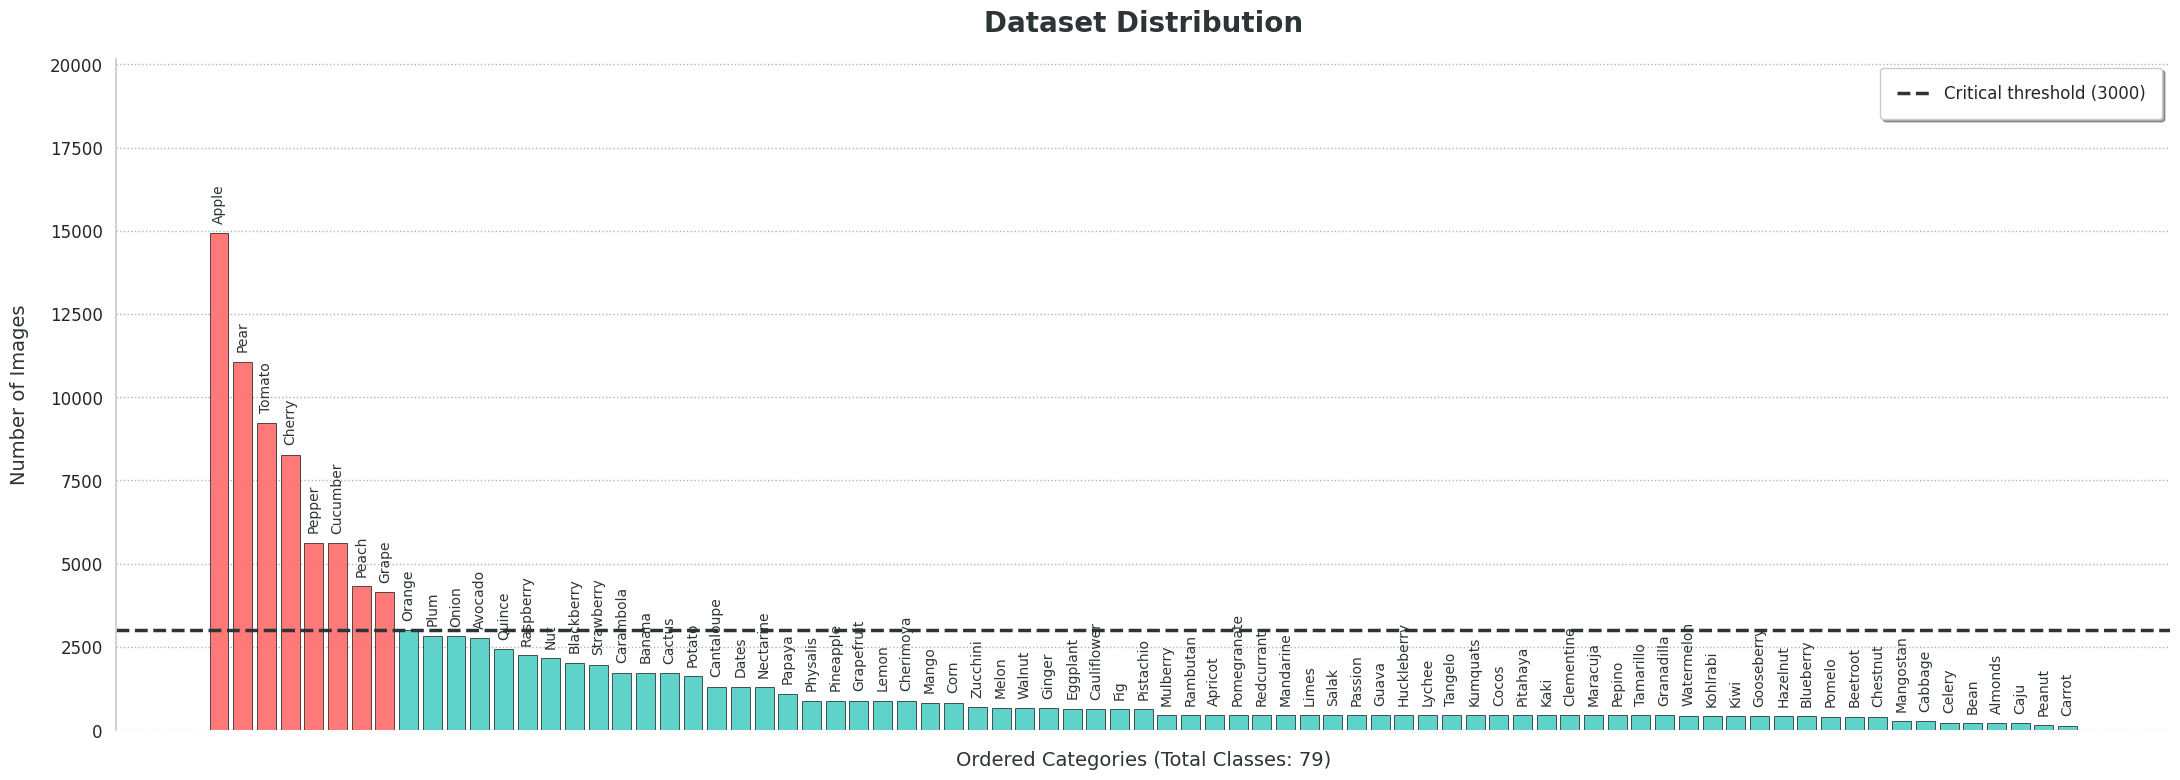

In [12]:
# Define the critical threshold for the Training set.
THRESHOLD_TRAINING = 3000
# Call the function to plot the class distribution for the Training set.
plot_class_distribution(TRAINING_PATH, THRESHOLD_TRAINING)

### Validation

Generating plot for: /content/fruits_dataset/Validation...


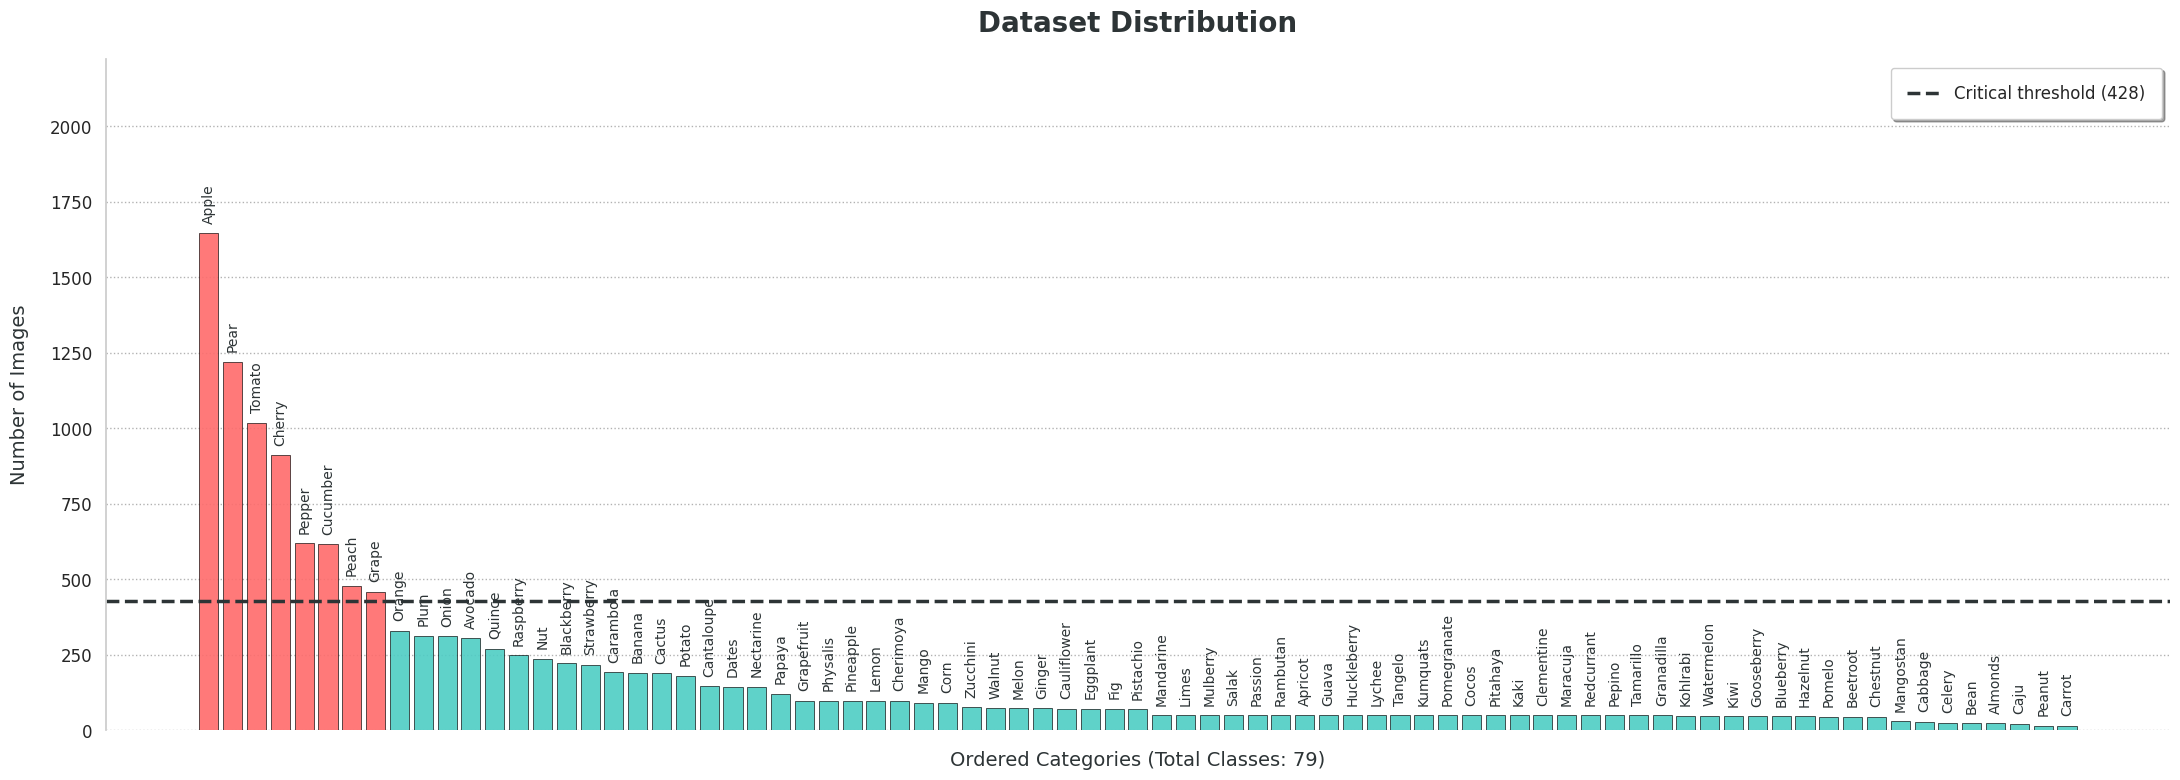

In [13]:
# Define the critical threshold for the Validation set, calculated previously.
THRESHOLD_VALIDATION = 428
# Call the function to plot the class distribution for the Validation set.
plot_class_distribution(VALIDATION_PATH, THRESHOLD_VALIDATION)

### Test

Generating plot for: /content/fruits_dataset/Test...


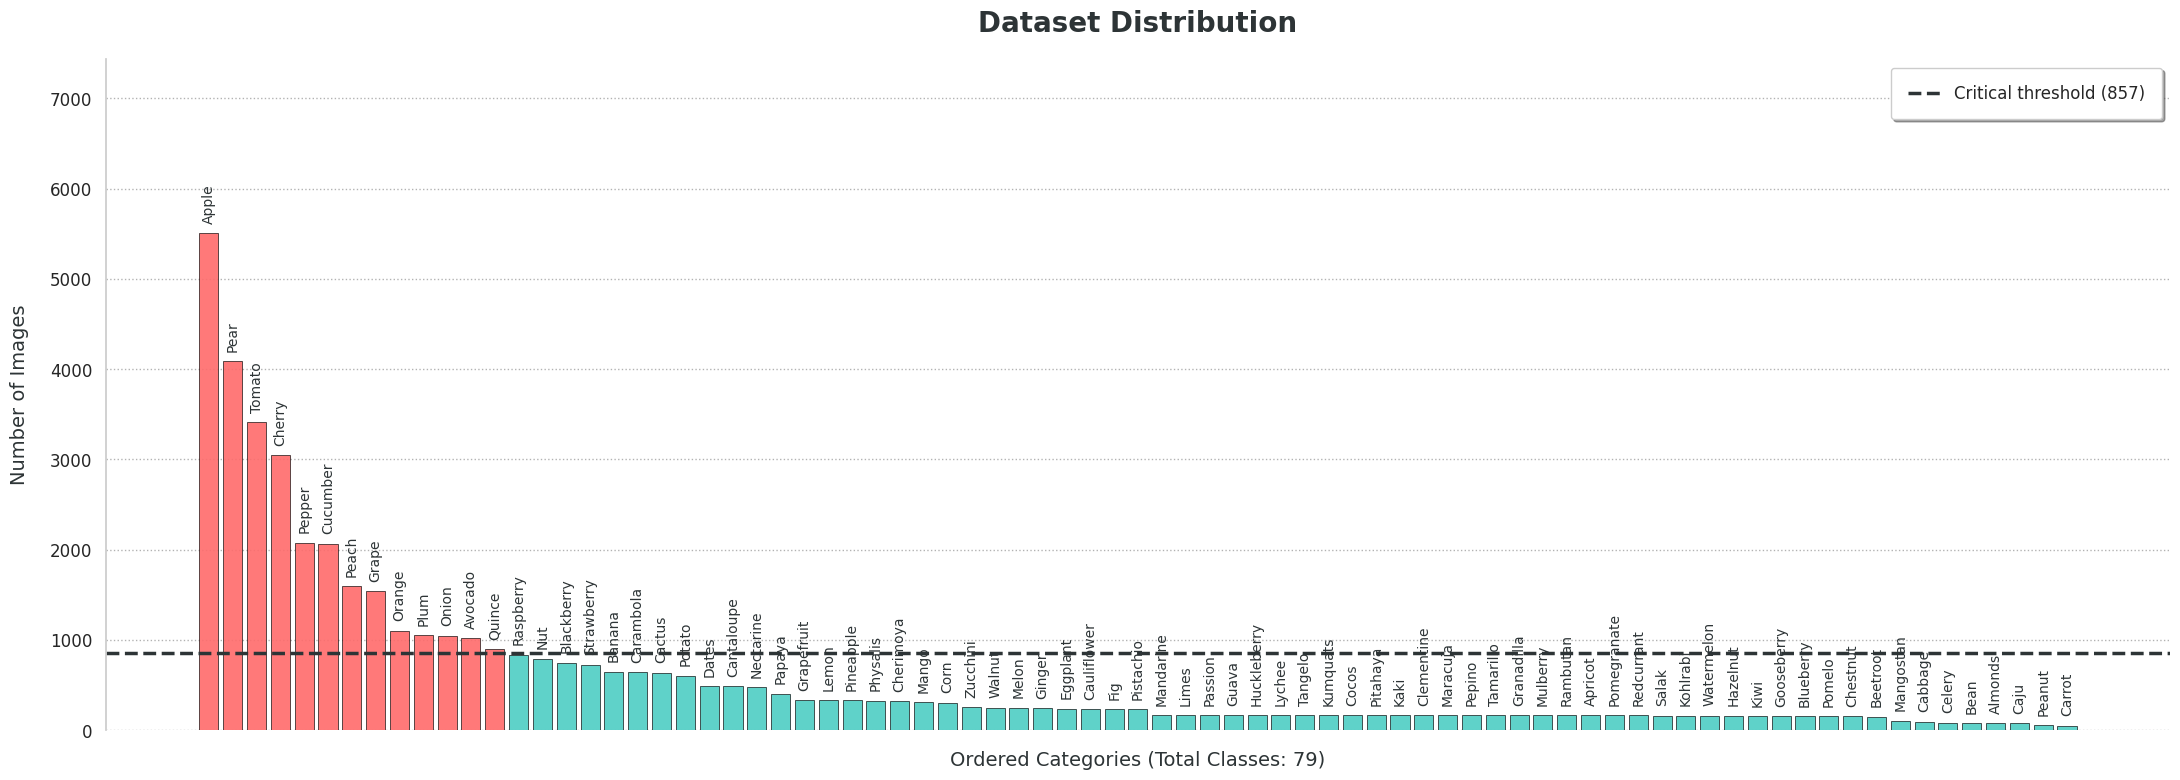

In [14]:
# Define the critical threshold for the Test set, calculated previously.
THRESHOLD_TEST = 857
# Call the function to plot the class distribution for the Test set.
plot_class_distribution(TEST_PATH, THRESHOLD_TEST)

## 5. Balanceo y aumento de datos

In [15]:
def balance_dataset(dataset_path, critical_min, target_count):
    """
    Filters, crops, and augments images in a dataset to achieve perfect balance
    or remove categories with very few data points.

    Args:
        dataset_path (str): Path to the root directory of the dataset.
        critical_min (int): Minimum number of images for a category to be considered valid.
        target_count (int): Target number of images per category after balancing.

    Returns:
        tuple: A tuple containing (images_removed, classes_removed).
    """
    if not os.path.exists(dataset_path):
        print(f"Error! Path not found: {dataset_path}")
        return 0, 0

    images_removed = 0
    classes_removed = 0

    # Get all categories.
    categories = [c for c in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, c))]

    for category in categories:
        category_path = os.path.join(dataset_path, category)

        # Count current images in the category.
        all_images = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        current_count = len(all_images)

        # Remove: If a category has fewer images than the critical minimum.
        if current_count < critical_min:
            print(f"Deleting '{category}' outright due to insufficient data ({current_count} images).")
            shutil.rmtree(category_path) # Delete the entire category directory.
            images_removed += current_count
            classes_removed += 1
            continue # Move to the next category.

        # Crop: If a category has more images than the target count.
        elif current_count > target_count:
            print(f"Cropping excess in '{category}': {current_count} -> {target_count}")
            random.shuffle(all_images) # Shuffle images for random cropping.
            images_to_delete = all_images[target_count:] # Select images to delete.

            for img_name in images_to_delete:
                os.remove(os.path.join(category_path, img_name))
            images_removed += (current_count - target_count)

    return images_removed, classes_removed

In [16]:
def sync_categories(source_path, target_path):
    """
    Synchronizes the categories of 'target_path' to match those of 'source_path'.
    Deletes any folder in 'target_path' that does not exist in 'source_path'.
    To ensure that the Test and Validation sets only contain the categories that
    remained in the Training set after balancing.

    Args:
        source_path (str): Path to the reference dataset.
        target_path (str): Path to the dataset to be synchronized.

    Returns:
        tuple: A tuple containing (images_removed, classes_removed).
    """
    source_name = os.path.basename(source_path)
    target_name = os.path.basename(target_path)

    print()
    print(f"Synchronizing '{target_name}' with '{source_name}'")

    if not os.path.exists(source_path) or not os.path.exists(target_path):
        print("Error! Check that both paths exist in your directory.")
        return 0, 0

    images_removed = 0
    classes_removed = 0

    # Get only the folder names from both paths.
    source_categories = set([c for c in os.listdir(source_path) if os.path.isdir(os.path.join(source_path, c))])
    target_categories = set([c for c in os.listdir(target_path) if os.path.isdir(os.path.join(target_path, c))])

    # Find and delete excess folders in 'target_path' (those not in 'source_path').
    categories_to_delete = target_categories - source_categories

    if not categories_to_delete:
        print(f"OK: '{target_name}' has no excess classes.")
    else:
        for category in categories_to_delete:
            cat_path = os.path.join(target_path, category)
            # Count images before deleting the category
            num_images_in_deleted_category = len([f for f in os.listdir(cat_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
            images_removed += num_images_in_deleted_category
            classes_removed += 1 # Increment class removed counter
            print(f"Deleting category '{category}' from '{target_name}' ({num_images_in_deleted_category} images) as it's not in '{source_name}'.")
            shutil.rmtree(cat_path) # Delete the directory of the excess category.

    print(f"Synchronization finished for {target_name}")
    return images_removed, classes_removed

### Training

Deleting 'Walnut' outright due to insufficient data (662 images).
Deleting 'Mandarine' outright due to insufficient data (441 images).
Deleting 'Ginger' outright due to insufficient data (661 images).
Deleting 'Bean' outright due to insufficient data (210 images).
Deleting 'Limes' outright due to insufficient data (441 images).
Deleting 'Melon' outright due to insufficient data (665 images).
Deleting 'Cauliflower' outright due to insufficient data (632 images).
Deleting 'Mulberry' outright due to insufficient data (443 images).
Deleting 'Salak' outright due to insufficient data (441 images).
Deleting 'Passion' outright due to insufficient data (441 images).
Deleting 'Rambutan' outright due to insufficient data (443 images).
Deleting 'Kiwi' outright due to insufficient data (420 images).
Cropping excess in 'Apple': 14925 -> 3000
Deleting 'Apricot' outright due to insufficient data (443 images).
Deleting 'Guava' outright due to insufficient data (441 images).
Cropping excess in 'Cucumber

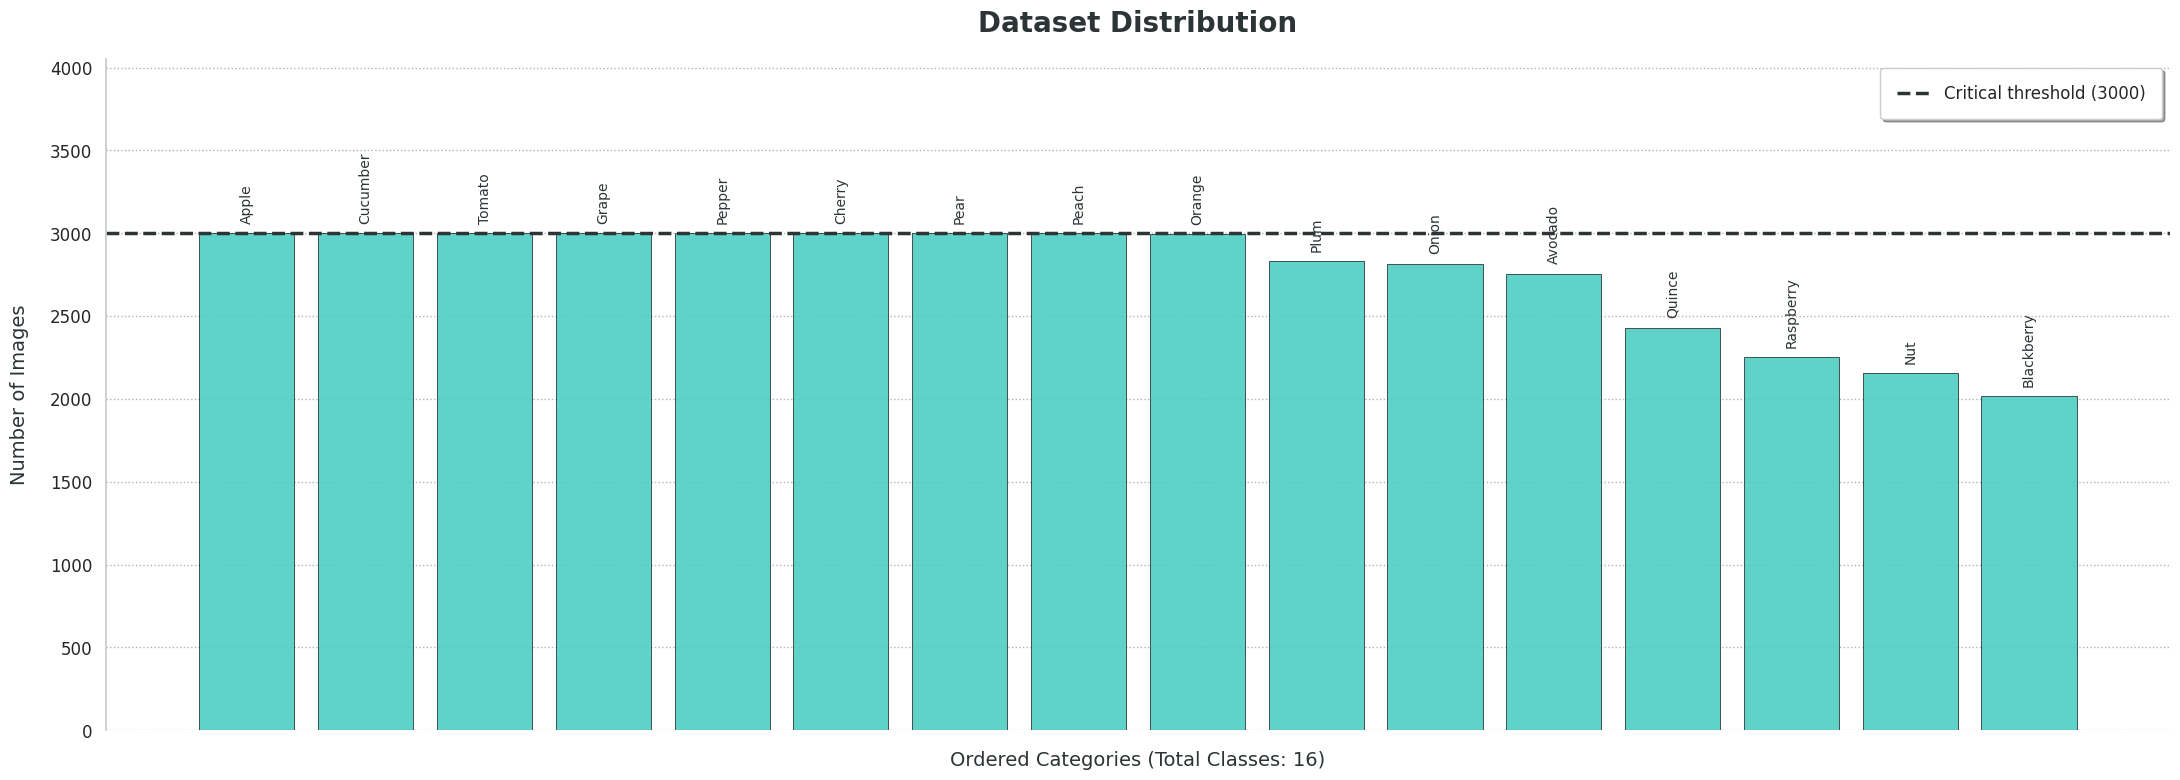

Deleted images in Training: 79335
Deleted classes in Training: 63


In [17]:
# Initialize counters for total images and classes removed across all datasets
total_images_removed = 0
total_classes_removed = 0

# Define the minimum number of images for a category and the target threshold for Training.
CRITICAL_MIN = 2000
THRESHOLD_TRAINING = 3000

# Apply the data balancing and augmentation function to the Training set.
images_removed_training, classes_removed_train = balance_dataset(TRAINING_PATH, CRITICAL_MIN, THRESHOLD_TRAINING)

# Re-plot the class distribution after balancing for Training.
plot_class_distribution(TRAINING_PATH, THRESHOLD_TRAINING)

print(f"Deleted images in Training: {images_removed_training}")
print(f"Deleted classes in Training: {classes_removed_train}")

### Validation

Cropping excess in 'Apple': 1646 -> 428
Cropping excess in 'Cucumber': 616 -> 428
Cropping excess in 'Tomato': 1018 -> 428
Cropping excess in 'Grape': 458 -> 428
Cropping excess in 'Pepper': 619 -> 428
Cropping excess in 'Cherry': 910 -> 428
Cropping excess in 'Pear': 1221 -> 428
Cropping excess in 'Peach': 478 -> 428

Synchronizing 'Validation' with 'Training'
Deleting category 'Dates' from 'Validation' (144 images) as it's not in 'Training'.
Deleting category 'Tangelo' from 'Validation' (49 images) as it's not in 'Training'.
Deleting category 'Pineapple' from 'Validation' (98 images) as it's not in 'Training'.
Deleting category 'Lychee' from 'Validation' (49 images) as it's not in 'Training'.
Deleting category 'Pistachio' from 'Validation' (69 images) as it's not in 'Training'.
Deleting category 'Hazelnut' from 'Validation' (46 images) as it's not in 'Training'.
Deleting category 'Pomegranate' from 'Validation' (49 images) as it's not in 'Training'.
Deleting category 'Kumquats' from 

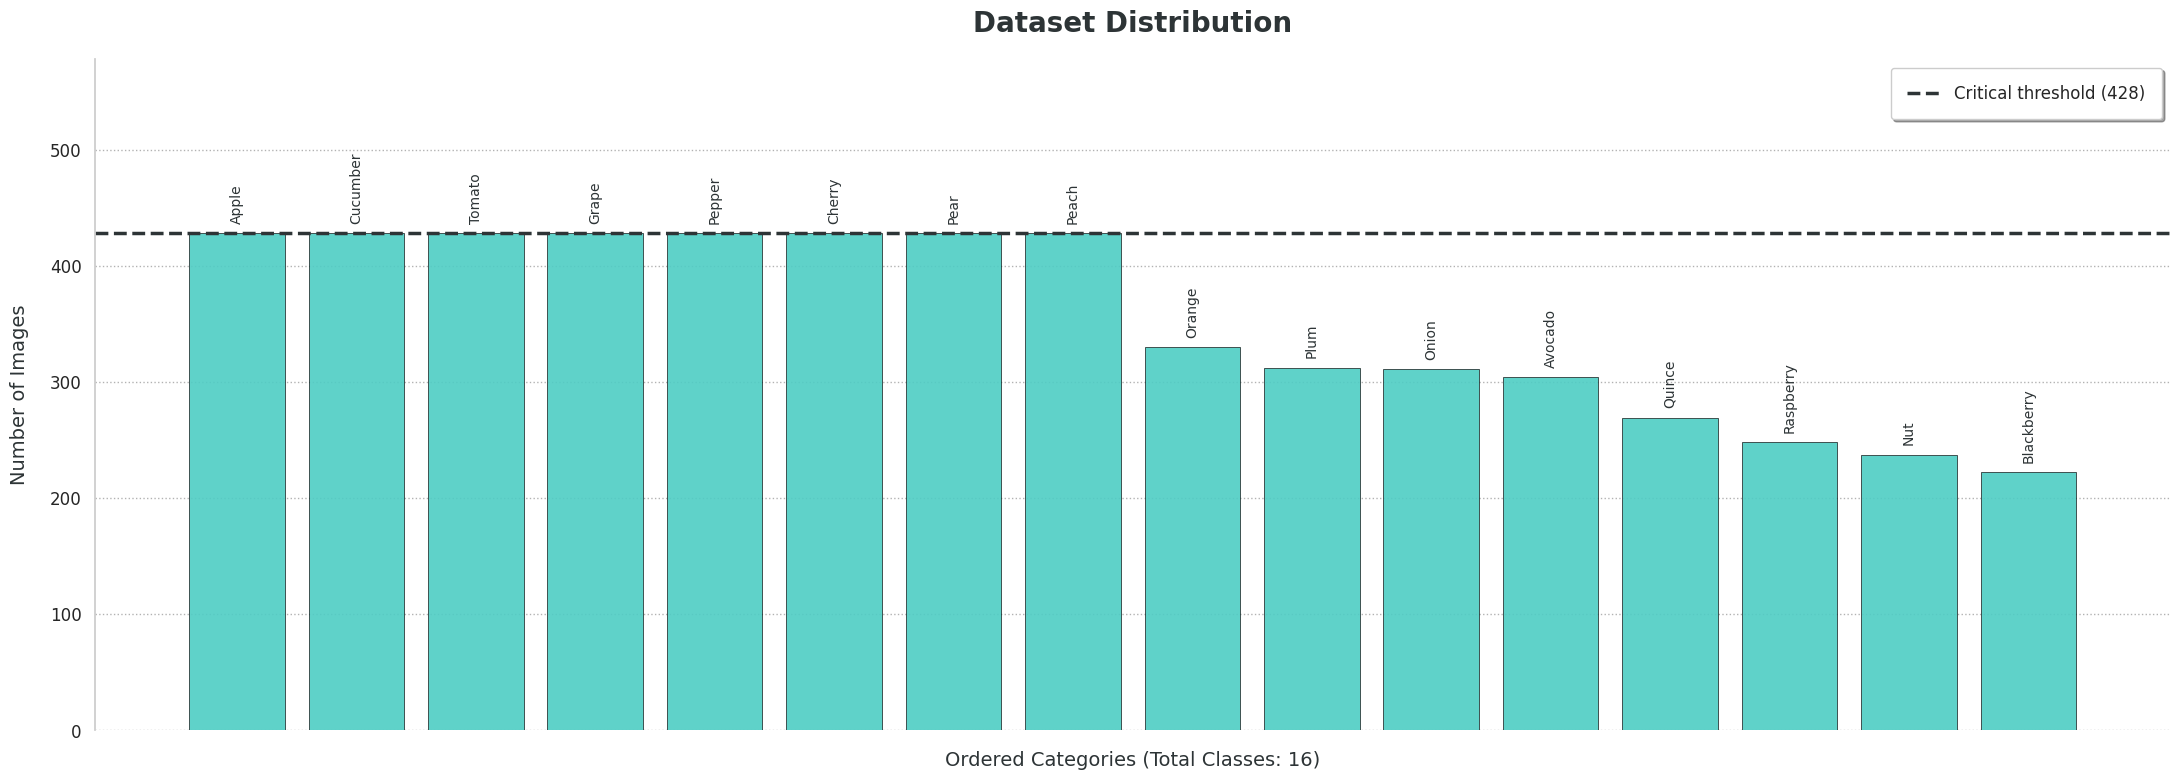

Deleted images in Validation: 7978
Deleted classes in Validation: 63


In [18]:
# Define the critical threshold for the Validation set.
THRESHOLD_VALIDATION = 428

# Balance the Validation set (critical_min is 0 as class removal already handled by training set)
images_removed_validation, _ = balance_dataset(VALIDATION_PATH, 0, THRESHOLD_VALIDATION)

# Synchronize the categories of the Validation set with those of the Training set.
images_removed_val_sync, classes_removed_validation = sync_categories(TRAINING_PATH, VALIDATION_PATH)
images_removed_validation += images_removed_val_sync

# Re-plot the class distribution after balancing and synchronization for Validation.
plot_class_distribution(VALIDATION_PATH, THRESHOLD_VALIDATION)

print(f"Deleted images in Validation: {images_removed_validation}")
print(f"Deleted classes in Validation: {classes_removed_validation}")

### Test

Cropping excess in 'Apple': 5506 -> 428
Cropping excess in 'Cucumber': 2065 -> 428
Cropping excess in 'Cactus': 634 -> 428
Cropping excess in 'Tomato': 3413 -> 428
Cropping excess in 'Grape': 1538 -> 428
Cropping excess in 'Plum': 1053 -> 428
Cropping excess in 'Dates': 485 -> 428
Cropping excess in 'Banana': 645 -> 428
Cropping excess in 'Nut': 793 -> 428
Cropping excess in 'Onion': 1045 -> 428
Cropping excess in 'Potato': 601 -> 428
Cropping excess in 'Blackberry': 745 -> 428
Cropping excess in 'Pepper': 2074 -> 428
Cropping excess in 'Nectarine': 477 -> 428
Cropping excess in 'Quince': 897 -> 428
Cropping excess in 'Avocado': 1017 -> 428
Cropping excess in 'Carambola': 642 -> 428
Cropping excess in 'Cherry': 3048 -> 428
Cropping excess in 'Orange': 1102 -> 428
Cropping excess in 'Raspberry': 833 -> 428
Cropping excess in 'Cantaloupe': 484 -> 428
Cropping excess in 'Strawberry': 725 -> 428
Cropping excess in 'Pear': 4087 -> 428
Cropping excess in 'Peach': 1597 -> 428

Synchronizing '

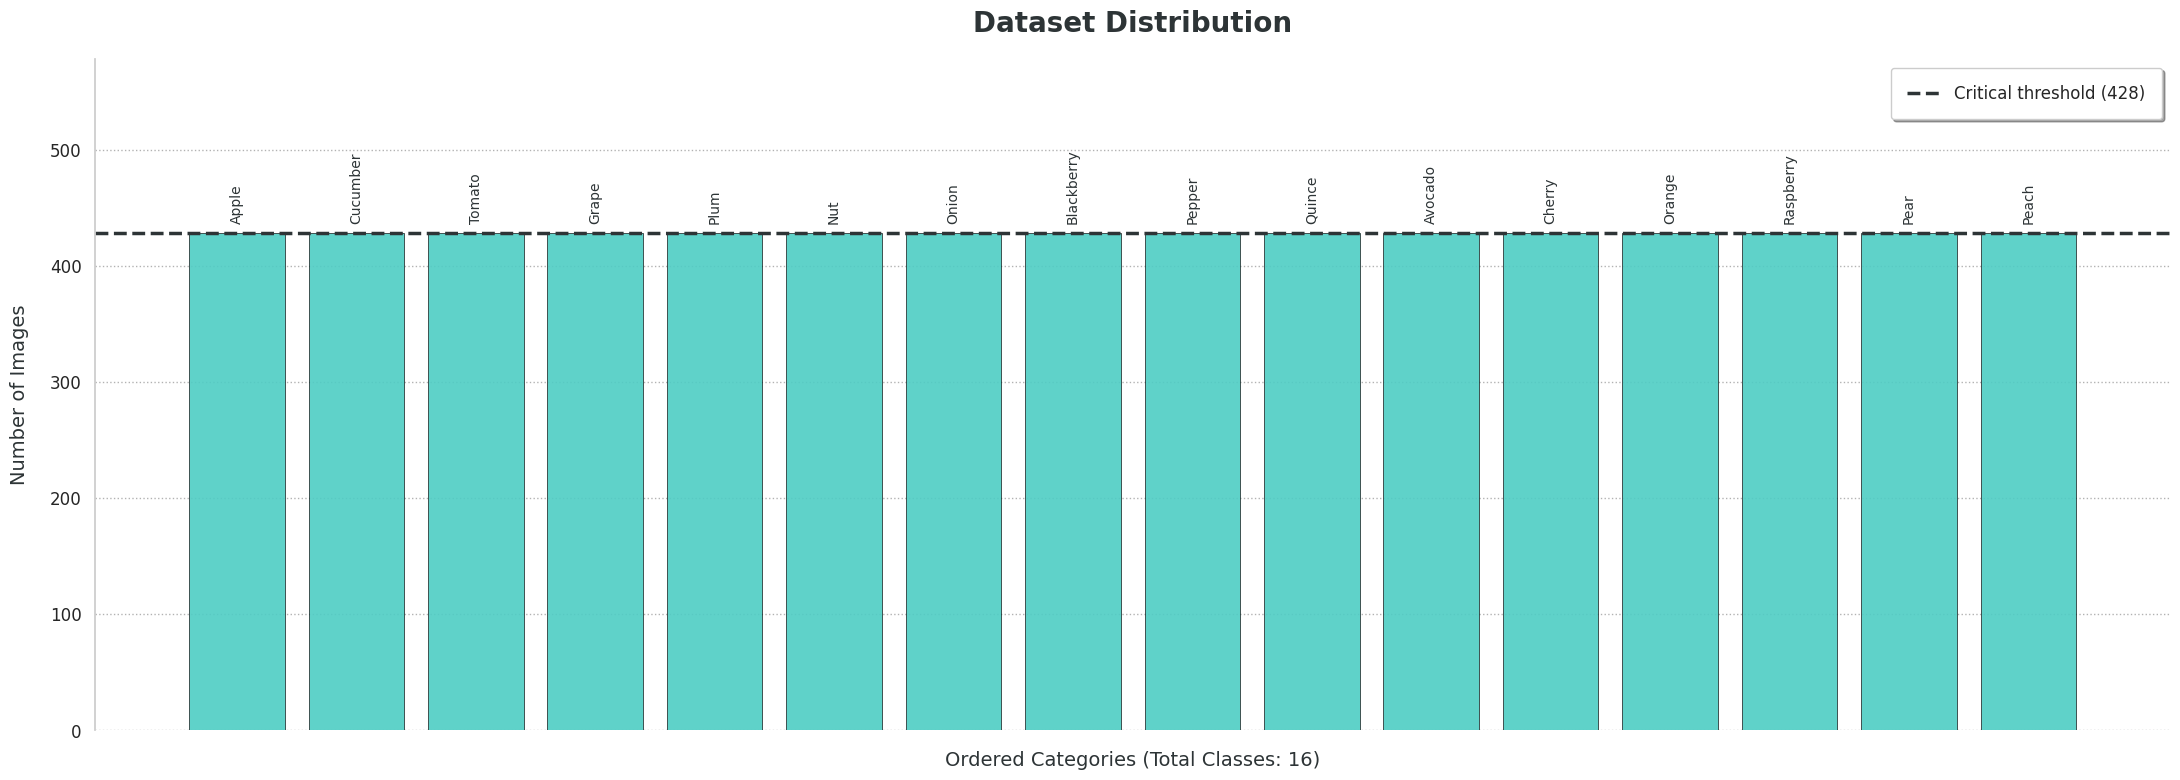

Deleted images in Testing: 38876
Deleted classes in Validation: 63


In [19]:
# Define the critical threshold for the Test set.
THRESHOLD_TEST = 428

# Balance the Test set (critical_min is 0 as class removal already handled by training set)
images_removed_testing, _ = balance_dataset(TEST_PATH, 0, THRESHOLD_TEST)

# Synchronize the categories of the Test set with those of the Training set.
images_removed_test_sync, classes_removed_testing = sync_categories(TRAINING_PATH, TEST_PATH)
images_removed_testing += images_removed_test_sync

# Re-plot the class distribution after balancing
plot_class_distribution(TEST_PATH, THRESHOLD_TEST)

print(f"Deleted images in Testing: {images_removed_testing}")
print(f"Deleted classes in Validation: {classes_removed_testing}")

In [23]:
print(f"Total images removed: {images_removed_training + images_removed_validation + images_removed_testing}")
print(f"Total classes removed: {classes_removed_train}")

Total images removed: 126189
Total classes removed: 63


In [22]:
# Get the list of remaining classes from the Training set
# Since validation and test sets are synchronized with training, this will give all final classes.
final_classes = sorted([d for d in os.listdir(TRAINING_PATH)])

print(f"Total de clases finales: {len(final_classes)}")
print("Nombres de las clases finales:")
for class_name in final_classes:
    print(f"- {class_name}")

Total de clases finales: 16
Nombres de las clases finales:
- Apple
- Avocado
- Blackberry
- Cherry
- Cucumber
- Grape
- Nut
- Onion
- Orange
- Peach
- Pear
- Pepper
- Plum
- Quince
- Raspberry
- Tomato


In [21]:
import shutil
from google.colab import files

# Create a zip archive of the dataset
output_filename = 'fruits_dataset_balanced'
shutil.make_archive(output_filename, 'zip', DATASET_PATH)

# Download the zip file
files.download(f'{output_filename}.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>